# Baseline DenseNet121 - CEDAR Dataset Evaluation

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from models.feature_extractor import DenseNetFeatureExtractor
from utils.model_evaluation   import (compute_metrics, _plot_det_curve,
                                       _plot_far_frr, _plot_confusion_matrix,
                                       _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
NOTEBOOK_NAME = 'baseline_cedar'
DATASET       = 'cedar'
DATASET_NAME  = 'CEDAR'

SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'baseline_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)

SPLIT_RATIOS = ['70_15_15']

IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4

EPOCHS              = 100
BATCH_SIZE          = 30
LR                  = 1e-3
MOMENTUM            = 0.99
WEIGHT_DECAY        = 0.0
EARLY_STOP_PATIENCE = 10

print(f" > [Config] Epochs: {EPOCHS} | LR: {LR} | "
      f"Momentum (beta1): {MOMENTUM} | Batch: {BATCH_SIZE}")
print(f" > [Config] Freezing: None (full fine-tuning)")
print(f" > [Config] Early stopping patience: {EARLY_STOP_PATIENCE} ")

 > [Config] Epochs: 100 | LR: 0.001 | Momentum (beta1): 0.99 | Batch: 30
 > [Config] Freezing: None (full fine-tuning)
 > [Config] Early stopping patience: 10 


## Step 3 — Transforms

In [3]:
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > [Transforms] train_transform: augmentation ON")
print(" > [Transforms] val_transform  : augmentation OFF")

 > [Transforms] train_transform: augmentation ON
 > [Transforms] val_transform  : augmentation OFF


## Step 4 — Datasets

In [4]:
class SplitDataset(Dataset):
    """
    Binary classification dataset for baseline DenseNet-121.

    Returns (image_tensor, label) where:
        label = 0  →  Genuine signature
        label = 1  →  Forged signature

    Writer-disjoint splits are enforced by the JSON split file structure
    produced by prepare_split_ratios.py. Writers in train, val, and test
    sets are completely non-overlapping — verified at runtime by assertions
    in Step 6.

    Args:
        user_dict (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        transform (callable) : Image transform pipeline.
    """

    def __init__(self, user_dict, transform=None):
        self.samples   = []
        self.transform = transform

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in
                             ('genuine', 'gen')), None)
            forg_key = next((k for k in data if k.lower() in
                             ('forged', 'forgeries', 'forg')), None)

            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []

            for path in gen_paths:
                self.samples.append((path, 0))   # 0 = Genuine
            for path in forg_paths:
                self.samples.append((path, 1))   # 1 = Forged

        n_gen  = sum(1 for _, l in self.samples if l == 0)
        n_forg = sum(1 for _, l in self.samples if l == 1)
        print(f"   Dataset: {len(self.samples)} samples "
              f"({n_gen} genuine + {n_forg} forged) | "
              f"{len(user_dict)} writers")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except Exception:
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label

print(" > [Dataset] SplitDataset defined")

 > [Dataset] SplitDataset defined


## Step 5 — Training Utilities

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    """
    One epoch of classification training with AMP.

    Args:
        model     (DenseNetFeatureExtractor)
        loader    (DataLoader)
        optimizer (torch.optim.Adam)
        criterion (nn.CrossEntropyLoss)
        device    (torch.device)
        scaler    (torch.amp.GradScaler)

    Returns:
        avg_loss (float), accuracy (float)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)              # [B, 2] raw logits
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_epoch(model, loader, criterion, device):
    """
    Compute validation loss and verification metrics for one epoch.

    Scoring convention:
        Softmax probability of class 0 (Genuine) is used as the
        verification score. compute_metrics expects higher score =
        more likely positive (genuine). EER threshold is computed on
        this scale, producing an intuitive decision rule:

            GENUINE  if  P(Genuine) >= threshold
            FORGED   if  P(Genuine) <  threshold

        This matches the proposed model's convention where higher
        similarity score = more genuine.

        Labels passed to compute_metrics use pos_label=1 for genuine,
        which aligns with the dataset convention (label=0 for forged,
        label=1 for genuine in SplitPairDataset). Since SplitDataset
        uses label=0 for genuine and label=1 for forged, we invert the
        labels here so that compute_metrics correctly identifies the
        genuine class as the positive class.

    Args:
        model     (DenseNetFeatureExtractor)
        loader    (DataLoader)
        criterion (nn.CrossEntropyLoss)
        device    (torch.device)

    Returns:
        val_loss (float), metrics (dict) — scalar metrics only,
        no curve data arrays.
    """
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs    = model(images)           # [B, 2]
            loss       = criterion(outputs, labels)
            total_loss += loss.item()

            # P(Genuine) as verification score — higher = more genuine.
            # index 0 = Genuine class (label=0 in SplitDataset).
            probs = torch.softmax(outputs, dim=1)[:, 0]   # [B]

            # Invert labels: SplitDataset uses 0=Genuine, 1=Forged.
            # compute_metrics expects 1=positive (genuine), 0=negative (forged).
            # Inverting: 0 → 1 (genuine becomes positive), 1 → 0 (forged becomes negative).
            inverted_labels = (1 - labels).cpu().numpy().tolist()

            all_scores.extend(probs.cpu().numpy().tolist())
            all_labels.extend(inverted_labels)

    # return_curve_data=False — scalar metrics only.
    # Keeps best_metrics clean for checkpoint saving (no numpy arrays).
    metrics = compute_metrics(all_labels, all_scores, return_curve_data=False)
    return total_loss / len(loader), metrics


def evaluate_model(model, loader, device, output_dir=None, silent=False):
    """
    Final evaluation with optional plot generation.

    Uses return_curve_data=True internally so ROC, DET, FAR/FRR, and
    score distribution plots can be generated. Called only once at the
    end of training for final test evaluation — not during the training loop.

    Args:
        model      (DenseNetFeatureExtractor)
        loader     (DataLoader)
        device     (torch.device)
        output_dir (str, optional) : Directory to save evaluation plots.
        silent     (bool)          : Suppress print output.

    Returns:
        dict: Full metrics dictionary including curve data for plots.
    """
    model.eval()
    all_labels = []
    all_scores = []

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)[:, 0]   # P(Genuine)

            inverted_labels = (1 - labels).cpu().numpy().tolist()
            all_scores.extend(probs.cpu().numpy().tolist())
            all_labels.extend(inverted_labels)

    # return_curve_data=True — needed for plot generation
    metrics = compute_metrics(all_labels, all_scores, return_curve_data=True)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',       ':.2%'),
                       ('auc',       ':.4f'),
                       ('threshold', ':.4f'),
                       ('accuracy',  ':.2%'),
                       ('precision', ':.2%'),
                       ('recall',    ':.2%'),
                       ('f1',        ':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


def run_training(train_loader, val_loader, device,
                 epochs, lr, momentum, weight_decay,
                 checkpoint_path):
    """
    Baseline training loop — replicates Kandeil et al. (2023).

    No backbone freezing. No phase transition. Full fine-tuning
    from epoch 1 throughout all epochs, consistent with the paper's
    transfer learning and fine-tuning description.

    Scoring convention:
        P(Genuine) is used as the verification score throughout.
        compute_metrics receives inverted labels (genuine=1, forged=0)
        so the EER threshold is computed on the P(Genuine) scale.
        Decision rule: GENUINE if P(Genuine) >= threshold.
        This aligns with the proposed model and produces an intuitive
        threshold value (~0.50–0.70) rather than an inverted value (~0.90).

    Checkpoint format:
        {
            'model_state_dict': state_dict,
            'metrics': {
                'eer':       float,
                'auc':       float,
                'threshold': float,   ← P(Genuine) EER threshold, read by app.py
                'accuracy':  float,
                'precision': float,
                'recall':    float,
                'f1':        float,
            }
        }

    Optimizer : Adam (paper: Adam, lr=0.001, momentum=0.99)
    Loss      : CrossEntropyLoss (paper: categorical_crossentropy)
    Scheduler : ReduceLROnPlateau on val EER — addition beyond paper.
    Early stop: On val EER, patience=EARLY_STOP_PATIENCE — addition
                beyond paper, included to prevent overfitting.

    Args:
        train_loader   (DataLoader)
        val_loader     (DataLoader)
        device         (torch.device)
        epochs         (int)   : Max epochs (paper: 100).
        lr             (float) : Learning rate (paper: 0.001).
        momentum       (float) : Adam beta1 (paper: 0.99).
        weight_decay   (float) : L2 penalty (paper: not specified, use 0).
        checkpoint_path(str)   : Path to save best model checkpoint.

    Returns:
        model        (DenseNetFeatureExtractor)
        best_metrics (dict)
        history      (dict)
    """
    print(f"\n   {'─'*60}")
    print(f"   BASELINE TRAINING  |  Kandeil et al. (2023)")
    print(f"   Epochs: {epochs} max  |  LR: {lr}  |  "
          f"beta1: {momentum}  |  Batch: {BATCH_SIZE}")
    print(f"   Freezing: None (full fine-tuning from epoch 1)")
    print(f"   Early stop patience: {EARLY_STOP_PATIENCE}")
    print(f"   Score convention: P(Genuine) >= threshold → GENUINE")
    print(f"   {'─'*60}")

    # ── Model ─────────────────────────────────────────────────────────────────
    # baseline=True  : no CBAM, standard DenseNet-121 feature extraction
    # normalize=False: classification logits — L2 norm must not be applied
    # output_dim=2   : binary classification (Genuine=0, Forged=1)
    model = DenseNetFeatureExtractor(
        backbone_name='densenet121',
        output_dim=2,
        pretrained=True,
        baseline=True,
        normalize=False
    ).to(device)

    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Params: {n_train:,} / {n_total:,} trainable "
          f"(all — no freezing)")

    criterion = nn.CrossEntropyLoss()
    scaler    = torch.amp.GradScaler('cuda')

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        betas=(momentum, 0.999),
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=5, min_lr=1e-6
    )

    best_eer     = float('inf')
    best_acc     = 0.0
    best_metrics = {}
    trigger      = 0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'val_eer':    []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_metrics = evaluate_epoch(
            model, val_loader, criterion, device
        )
        val_eer = val_metrics['eer']
        val_acc = val_metrics['accuracy']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_eer'].append(val_eer)

        print(f"   Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")

        scheduler.step(val_eer)

        improved = (
            val_eer < best_eer or
            (val_eer == best_eer and val_acc > best_acc)
        )
        if improved:
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics

            # evaluate_epoch uses return_curve_data=False, so best_metrics
            # contains only scalar values — no filtering needed.
            torch.save({
                'model_state_dict': model.state_dict(),
                'metrics': {
                    k: float(v) for k, v in best_metrics.items()
                }
            }, checkpoint_path)
            print(f"   >>> Checkpoint saved  "
                  f"(Val EER: {val_eer:.2%} | "
                  f"Threshold: {val_metrics['threshold']:.4f})")
            trigger = 0
        else:
            trigger += 1
            if trigger >= EARLY_STOP_PATIENCE:
                print(f"   >>> Early stopping at epoch {epoch+1} "
                      f"(no improvement for {EARLY_STOP_PATIENCE} epochs)")
                break

    return model, best_metrics, history


print(" > [Utils] All training functions defined")

 > [Utils] All training functions defined


## Step 6 — Run All Splits

In [6]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR,
                                  f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")
    print(f" > [Config] Replicating Kandeil et al. (2023) — DenseNet121")
    print(f" > [Config] LR: {LR} | Momentum: {MOMENTUM} | "
          f"Batch: {BATCH_SIZE} | Epochs: {EPOCHS}")

    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})")
        continue

    with open(split_file) as f:
        split_data = json.load(f)

    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']

    # ── Writer-disjoint split verification ───────────────────────────────────
    # Confirms no writer appears in more than one split.
    # This is guaranteed by prepare_split_ratios.py but verified here
    # as a runtime safety check.
    train_writers = set(train_dict.keys())
    val_writers   = set(val_dict.keys())
    test_writers  = set(test_dict.keys())
    assert len(train_writers & val_writers)  == 0, \
        "DATA LEAK: writer overlap between train and val"
    assert len(train_writers & test_writers) == 0, \
        "DATA LEAK: writer overlap between train and test"
    assert len(val_writers   & test_writers) == 0, \
        "DATA LEAK: writer overlap between val and test"

    print(f"  Writers — Train: {len(train_dict)} | "
          f"Val: {len(val_dict)} | Test: {len(test_dict)}")
    print(f"  Split integrity: VERIFIED (no writer overlap)")

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_dataset = SplitDataset(train_dict, transform=train_transform)
    val_dataset   = SplitDataset(val_dict,   transform=val_transform)
    test_dataset  = SplitDataset(test_dict,  transform=val_transform)

    if len(train_dataset) == 0 or len(val_dataset) == 0 \
            or len(test_dataset) == 0:
        print("  SKIPPED: empty dataset")
        continue

    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    seed_everything(42)
    checkpoint_path = os.path.join(exp_dir, "best_baseline_model.pth")
    t0 = time.time()

    trained_model, best_val_metrics, history = run_training(
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        checkpoint_path=checkpoint_path
    )
    t_train = time.time() - t0

    # ── Loss + EER curve ──────────────────────────────────────────────────────
    n_epochs_run = len(history['train_loss'])
    epoch_axis   = list(range(1, n_epochs_run + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Baseline DenseNet-121 — {DATASET_NAME} ({split_label})\n'
        f'Kandeil et al. (2023) replication',
        fontsize=13, fontweight='bold'
    )

    ax1.plot(epoch_axis, history['train_loss'],
             label='Train Loss', color='steelblue', linewidth=2)
    ax1.plot(epoch_axis, history['val_loss'],
             label='Val Loss',   color='firebrick', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
    ax1.set_title('Train vs Validation Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(epoch_axis, history['val_eer'],
             label='Val EER', color='darkorchid', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('EER', fontsize=11)
    ax2.set_title('Validation EER', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    loss_plot_path = os.path.join(split_eval_dir, 'loss_curve.png')
    plt.savefig(loss_plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f" > Loss curve saved → {loss_plot_path}")

    # ── Load best checkpoint + final test evaluation ──────────────────────────
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=DEVICE,
                          weights_only=False)
        trained_model.load_state_dict(ckpt['model_state_dict'])
        print("   Best checkpoint reloaded for final test evaluation")

    final_metrics = evaluate_model(
        trained_model, test_loader, DEVICE,
        output_dir=split_eval_dir, silent=False
    )

    # ── Record results ────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':            DATASET_NAME,
        'split':              split_label,
        'train_users':        len(train_dict),
        'val_users':          len(val_dict),
        'test_users':         len(test_dict),
        'eer':                float(final_metrics['eer']),
        'accuracy':           float(final_metrics['accuracy']),
        'auc':                float(final_metrics['auc']),
        'precision':          float(final_metrics.get('precision', 0)),
        'recall':             float(final_metrics.get('recall',    0)),
        'f1':                 float(final_metrics.get('f1',        0)),
        'train_time_seconds': round(t_train, 2),
    }

    print(f"  RESULT [{split_label}]: "
          f"EER={final_metrics['eer']:.2%} | "
          f"Acc={final_metrics['accuracy']:.2%} | "
          f"AUC={final_metrics['auc']:.4f} | "
          f"F1={final_metrics.get('f1', 0):.4f} | "
          f"Time={t_train:.1f}s")


  CEDAR  —  70:15:15  Split
 > [Config] Replicating Kandeil et al. (2023) — DenseNet121
 > [Config] LR: 0.001 | Momentum: 0.99 | Batch: 30 | Epochs: 100
  Writers — Train: 38 | Val: 8 | Test: 9
  Split integrity: VERIFIED (no writer overlap)
   Dataset: 1824 samples (912 genuine + 912 forged) | 38 writers
   Dataset: 384 samples (192 genuine + 192 forged) | 8 writers
   Dataset: 432 samples (216 genuine + 216 forged) | 9 writers
 > [Seed] 42

   ────────────────────────────────────────────────────────────
   BASELINE TRAINING  |  Kandeil et al. (2023)
   Epochs: 100 max  |  LR: 0.001  |  beta1: 0.99  |  Batch: 30
   Freezing: None (full fine-tuning from epoch 1)
   Early stop patience: 10
   Score convention: P(Genuine) >= threshold → GENUINE
   ────────────────────────────────────────────────────────────
   Params: 6,957,954 / 6,957,954 trainable (all — no freezing)


Training:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 01/100 | Train Loss: 0.6651 | Val Loss: 1.9714 | Train Acc: 66.83% | Val EER: 39.06% | Val Acc: 60.94%
   >>> Checkpoint saved  (Val EER: 39.06% | Threshold: 0.9152)


Training:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 02/100 | Train Loss: 0.5146 | Val Loss: 2.6807 | Train Acc: 76.17% | Val EER: 25.52% | Val Acc: 74.48%
   >>> Checkpoint saved  (Val EER: 25.52% | Threshold: 0.0004)


...

   Epoch 12/100 | Train Loss: 0.1353 | Val Loss: 1.8882 | Train Acc: 94.44% | Val EER: 28.12% | Val Acc: 72.14%


Training:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 13/100 | Train Loss: 0.1202 | Val Loss: 2.3658 | Train Acc: 95.33% | Val EER: 28.65% | Val Acc: 71.35%


Training:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 14/100 | Train Loss: 0.0884 | Val Loss: 1.8783 | Train Acc: 96.61% | Val EER: 28.65% | Val Acc: 71.09%
   >>> Early stopping at epoch 14 (no improvement for 10 epochs)
 > Loss curve saved → /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/loss_curve.png
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 24.54%
  AUC          : 0.8320
  THRESHOLD    : 0.0040
  ACCURACY     : 76.39%
  PRECISION    : 75.91%
  RECALL       : 77.31%
  F1           : 76.61%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to

## Step 7 — Summary Table


                                   BASELINE DENSENET-121 — CEDAR                                    
                                 Replicating Kandeil et al. (2023)                                  
Split      Train    Val      Test          EER   Accuracy      AUC       F1    Time(s)
----------------------------------------------------------------------------------------------------
70:15:15   38       8        9          0.2454     0.7639   0.8320   0.7661      52.67

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_results.json


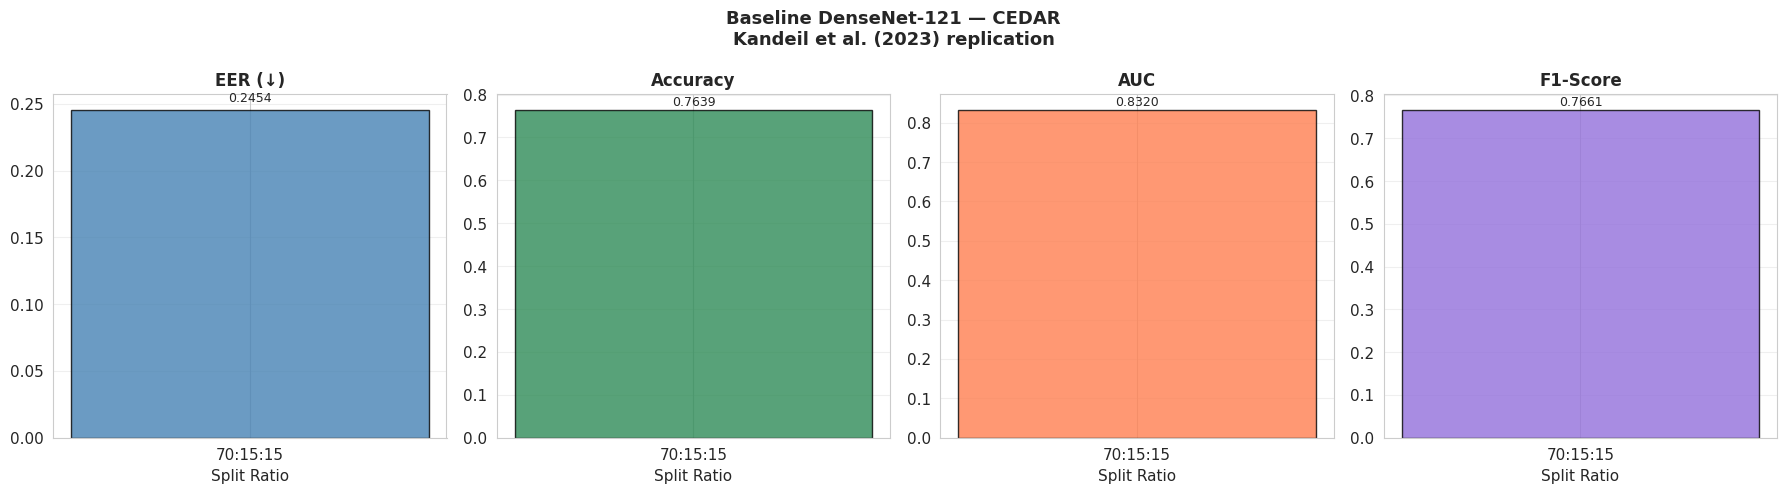

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_comparison.png


In [7]:
print(f"\n{'='*100}")
print(f"{'BASELINE DENSENET-121 — ' + DATASET_NAME:^100}")
print(f"{'Replicating Kandeil et al. (2023)':^100}")
print(f"{'='*100}")
print(f"{'Split':<10} {'Train':<8} {'Val':<8} {'Test':<8} "
      f"{'EER':>8} {'Accuracy':>10} {'AUC':>8} "
      f"{'F1':>8} {'Time(s)':>10}")
print(f"{'-'*100}")

for key, res in all_results.items():
    print(f"{res['split']:<10} {res['train_users']:<8} "
          f"{res['val_users']:<8} {res['test_users']:<8} "
          f"{res['eer']:>8.4f} {res['accuracy']:>10.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f} "
          f"{res['train_time_seconds']:>10.2f}")

print(f"{'='*100}")

# ── Save results JSON ─────────────────────────────────────────────────────────
results_path = os.path.join(CHECKPOINT_DIR,
                             f'baseline_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved → {results_path}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    f'Baseline DenseNet-121 — {DATASET_NAME}\n'
    f'Kandeil et al. (2023) replication',
    fontsize=13, fontweight='bold'
)

for ax, metric, title, color in zip(
        axes,
        ['eer',        'accuracy',  'auc',   'f1'],
        ['EER (↓)',    'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',  'seagreen',  'coral', 'mediumpurple']):

    labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [
        all_results.get(
            f"{DATASET_NAME} ({r.replace('_', ':')})", {}
        ).get(metric, 0)
        for r in SPLIT_RATIOS
    ]

    bars = ax.bar(labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR,
                          f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")

## Step 8 — Results Chart

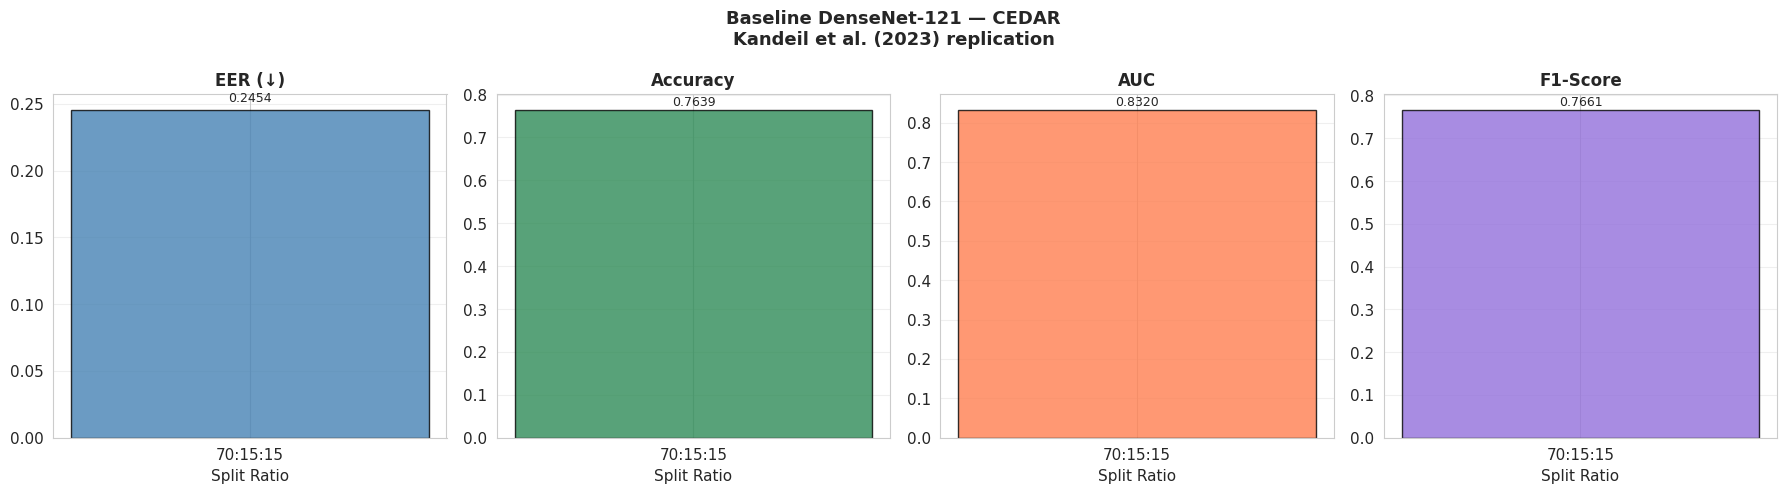

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_comparison.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    f'Baseline DenseNet-121 — {DATASET_NAME}\n'
    f'Kandeil et al. (2023) replication',
    fontsize=13, fontweight='bold'
)

for ax, metric, title, color in zip(
        axes,
        ['eer',        'accuracy',  'auc',   'f1'],
        ['EER (↓)',    'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',  'seagreen',  'coral', 'mediumpurple']):

    labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [
        all_results.get(
            f"{DATASET_NAME} ({r.replace('_', ':')})", {}
        ).get(metric, 0)
        for r in SPLIT_RATIOS
    ]

    bars = ax.bar(labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR,
                          f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")